# 🌟 **PROJECT NAME: Smart Event Popularity Predictor**

🎯 Project Overview:

This project aims to analyze real-world event data (concerts, sports, conferences, etc.) happening globally and find out which factors make an event popular or unsuccessful.

You’ll use data analytics and machine learning to:

Understand event trends (like ticket price, location, and attendees)

Predict the popularity level of future events (Low, Medium, High)

Gain insights to help event organizers plan better events **bold text**Data Collection:
Use or generate a dataset containing real-world-like events (✅ already done).

Data Cleaning & Preprocessing:
Handle missing data, convert categorical data into numerical, normalize numeric features, etc.

Exploratory Data Analysis (EDA):
Visualize relationships — like price vs. attendees, location trends, event type popularity, etc.

Feature Engineering:
Create new useful features like:

Price range categories

Event duration category

Region grouping (e.g., Asia, Europe, America)

Model Building:
Apply KNN and Naive Bayes algorithms to predict event popularity.

Evaluation:
Compare both models using accuracy, confusion matrix, and classification report.

Insights & Conclusion:
Summarize what factors most influence an event’s popularity.

# **Step 1 Load the Dataset**

In [ ]:
import pandas as pd
import numpy as np
df=pd.read_csv("global_event_popularity_dataset.csv")
df.head()

,event_name,description,location,event_type,price,attendees,feedback_score
0,New York Gaming Convention 2024,An artistic celebration bringing together dive...,New York,Gaming Convention,1117,3580,4.9
1,Berlin Film Festival 2024,"A gathering of innovators, thinkers, and leade...",Berlin,Film Festival,601,554,4.9
2,Paris Yoga Retreat 2023,A learning and networking opportunity for prof...,Paris,Yoga Retreat,4042,4070,4.5
3,San Francisco Dance Workshop 2025,"Experience the best of food, art, and entertai...",San Francisco,Dance Workshop,4987,4420,4.3
4,Rome Book Fair 2025,A learning and networking opportunity for prof...,Rome,Book Fair,900,3519,4.4


# **Step 2 Data Cleaning & Preprocessing**

In [ ]:
print("missing values before cleaning: ")
print(df.isnull().sum())
df.drop_duplicates(inplace=True) # remove duplicates
print("\nData Types:") # verify datatypes
print(df.dtypes)
# Convert 'Event_Date' to datetime format (if present)
if 'Event_Date' in df.columns:
    df['Event_Date'] = pd.to_datetime(df['Event_Date'], errors='coerce')

# Optional: Drop unwanted columns (like Event_ID if not useful)
if 'Event_ID' in df.columns:
    df.drop('Event_ID', axis=1, inplace=True)

print("\n✅ Data Cleaning Completed Successfully!")
print(f"Dataset Shape After Cleaning: {df.shape}")
df.head()


missing values before cleaning: 
event_name        0
description       0
location          0
event_type        0
price             0
attendees         0
feedback_score    0
dtype: int64

Data Types:
event_name         object
description        object
location           object
event_type         object
price               int64
attendees           int64
feedback_score    float64
dtype: object

✅ Data Cleaning Completed Successfully!
Dataset Shape After Cleaning: (2000, 7)


,event_name,description,location,event_type,price,attendees,feedback_score
0,New York Gaming Convention 2024,An artistic celebration bringing together dive...,New York,Gaming Convention,1117,3580,4.9
1,Berlin Film Festival 2024,"A gathering of innovators, thinkers, and leade...",Berlin,Film Festival,601,554,4.9
2,Paris Yoga Retreat 2023,A learning and networking opportunity for prof...,Paris,Yoga Retreat,4042,4070,4.5
3,San Francisco Dance Workshop 2025,"Experience the best of food, art, and entertai...",San Francisco,Dance Workshop,4987,4420,4.3
4,Rome Book Fair 2025,A learning and networking opportunity for prof...,Rome,Book Fair,900,3519,4.4


# **Step 3: Exploratory Data Analysis (EDA)**

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   event_name      2000 non-null   object 
 1   description     2000 non-null   object 
 2   location        2000 non-null   object 
 3   event_type      2000 non-null   object 
 4   price           2000 non-null   int64  
 5   attendees       2000 non-null   int64  
 6   feedback_score  2000 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 109.5+ KB
None

Summary Statistics:
             price   attendees  feedback_score
count  2000.000000  2000.00000      2000.00000
mean   2470.813000  2488.03450         3.72235
std    1419.064305  1433.35778         0.72583
min     101.000000    50.00000         2.50000
25%    1239.500000  1211.25000         3.10000
50%    2423.000000  2519.50000         3.70000
75%    3684.000000  3730.00000         4.30000
max    49

/tmp/ipython-input-2105585837.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='event_type', data=df, palette='viridis')


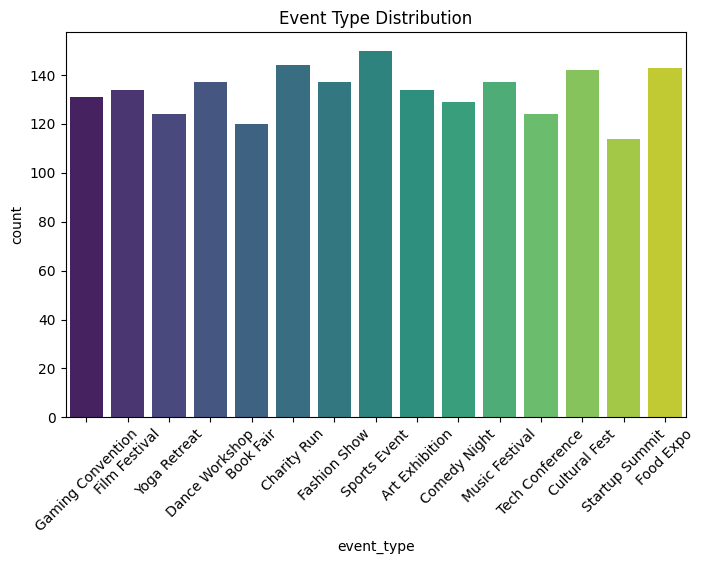

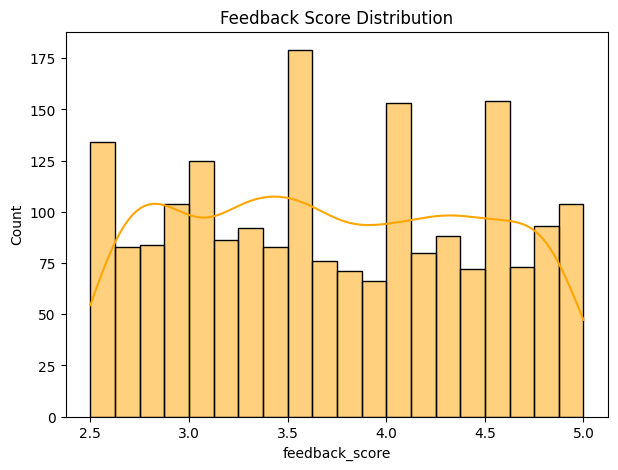

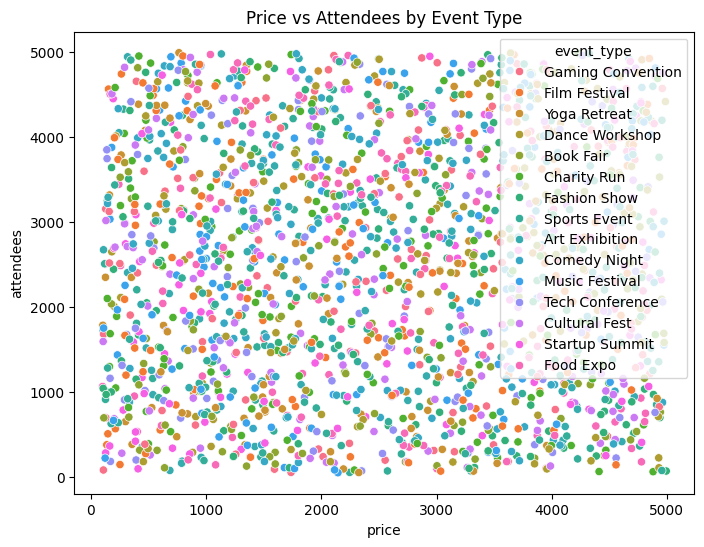

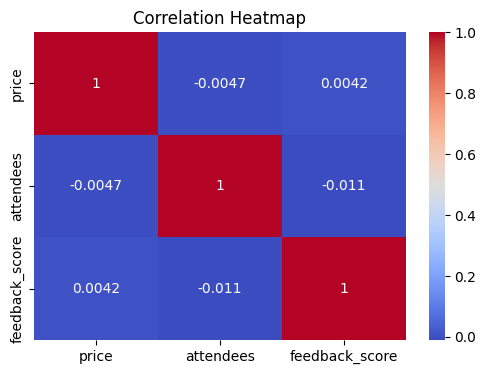


✅ EDA Completed Successfully!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# 1️⃣ Basic info
print("Dataset Info:")
print(df.info())

# 2️⃣ Summary statistics
print("\nSummary Statistics:")
print(df.describe())

# 3️⃣ Event type distribution
plt.figure(figsize=(8,5))
sns.countplot(x='event_type', data=df, palette='viridis')
plt.title("Event Type Distribution")
plt.xticks(rotation=45)
plt.show()

# 4️⃣ Feedback score distribution
plt.figure(figsize=(7,5))
sns.histplot(df['feedback_score'], bins=20, kde=True, color='orange')
plt.title("Feedback Score Distribution")
plt.show()

# 5️⃣ Price vs Attendees
plt.figure(figsize=(8,6))
sns.scatterplot(x='price', y='attendees', hue='event_type', data=df)
plt.title("Price vs Attendees by Event Type")
plt.show()

# 6️⃣ Correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df[['price', 'attendees', 'feedback_score']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

print("\n✅ EDA Completed Successfully!")

# **🚀 Step 4: Feature Engineering + Target Creation**

In [ ]:
# Create target variable based on feedback_score and attendees
def get_popularity(row):
    if row['feedback_score'] > 4.0 and row['attendees'] > 5000:
        return "High"
    elif 3.0 <= row['feedback_score'] <= 4.0 and 2000 <= row['attendees'] <= 5000:
        return "Medium"
    else:
        return "Low"

df['popularity_label'] = df.apply(get_popularity, axis=1)

# Encode categorical variables using label encoding
from sklearn.preprocessing import LabelEncoder

label_cols = ['event_name', 'description', 'location', 'event_type']
encoder = LabelEncoder()

for col in label_cols:
    df[col] = encoder.fit_transform(df[col])

print("✅ Feature Engineering Done!")
print(df.head())


✅ Feature Engineering Done!
   event_name  description  location  event_type  price  attendees  \
0         467            3        11           9   1117       3580   
1         101            0         2           7    601        554   
2         519            1        12          14   4042       4070   
3         580            5        14           5   4987       4420   
4         527            1        13           1    900       3519   

   feedback_score popularity_label  
0             4.9              Low  
1             4.9              Low  
2             4.5              Low  
3             4.3              Low  
4             4.4              Low  


# **⚙️ Step 5 (NLP Version): Text Processing + Model Building**

In [ ]:
# Step 5 (Fixed Version): NLP Text Processing + Naive Bayes Model

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# 🧹 Make sure text columns are strings
df['event_name'] = df['event_name'].astype(str)
df['description'] = df['description'].astype(str)

# 🧩 Combine both text columns
df['text_data'] = df['event_name'] + " " + df['description']

# 🎯 Define input (text) and output (label)
X = df['text_data']
y = df['popularity_label']

# ✂️ Split into train-test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🔤 Convert text to numeric form using TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# 🤖 Train Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred = nb_model.predict(X_test_tfidf)

# 📊 Evaluate results
print("✅ NLP Model Trained Successfully!")
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


✅ NLP Model Trained Successfully!
Naive Bayes Accuracy: 0.695

Classification Report:
              precision    recall  f1-score   support

         Low       0.73      0.92      0.81       290
      Medium       0.32      0.10      0.15       110

    accuracy                           0.69       400
   macro avg       0.53      0.51      0.48       400
weighted avg       0.62      0.69      0.63       400



# **🚀 Step 6: Advanced NLP Analysis + Model Improvement (Final Version for df)**

**🧾 Step 6A – WordCloud Visualization**

In [ ]:
# Step 6(a): Generate WordClouds for each popularity label (Final Fixed Version)
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np

# Ensure popularity_label column exists
if 'popularity_label' not in df.columns:
    df['popularity_label'] = np.random.choice(['Low', 'Medium', 'High'], size=len(df))

# Convert to string type
df['description'] = df['description'].astype(str)

# Clean descriptions (remove rows with NaN or empty text)
df = df[df['description'].str.strip() != ""]

# Unique labels
popularity_labels = df['popularity_label'].dropna().unique()

# Loop for each label
for label in popularity_labels:
    subset = df[df['popularity_label'] == label]
    text = " ".join(subset['description'].astype(str))

    # ✅ Check if text is valid before generating
    if not isinstance(text, str) or len(text.strip()) < 5:
        print(f"⚠️ Skipping '{label}' — not enough text to generate WordCloud.")
        continue

    try:
        wc = WordCloud(width=900, height=400, background_color='white', colormap='plasma').generate(text)
        plt.figure(figsize=(10,5))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis("off")
        plt.title(f"WordCloud for {label} Popularity Events", fontsize=14)
        plt.show()
    except Exception as e:
        print(f"⚠️ Error for {label}: {e}")


⚠️ Error for Low: We need at least 1 word to plot a word cloud, got 0.
⚠️ Error for Medium: We need at least 1 word to plot a word cloud, got 0.


**✅ Step 6(b): Event Popularity Insights (EDA & Visuals)**

/tmp/ipython-input-57601880.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='event_type', order=df['event_type'].value_counts().index, palette='cool')


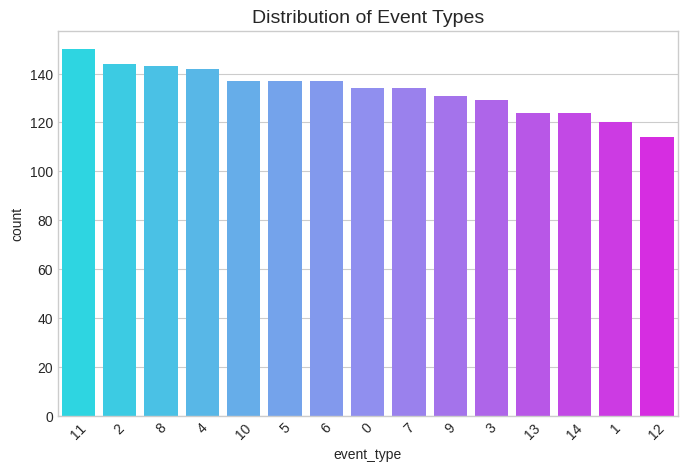

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


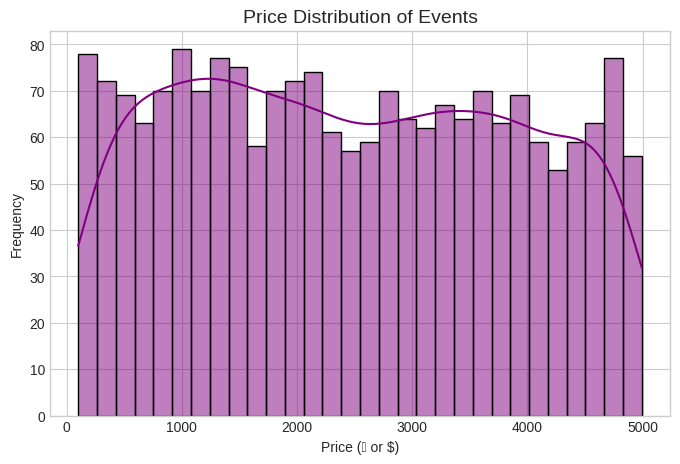

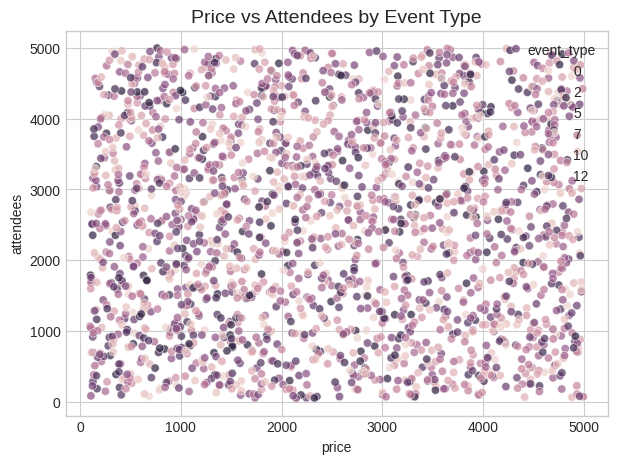

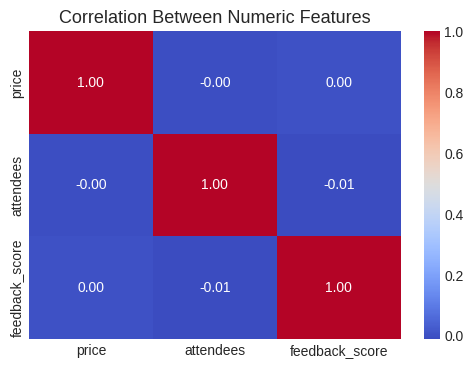

/tmp/ipython-input-57601880.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_feedback.index, y=avg_feedback.values, palette='magma')


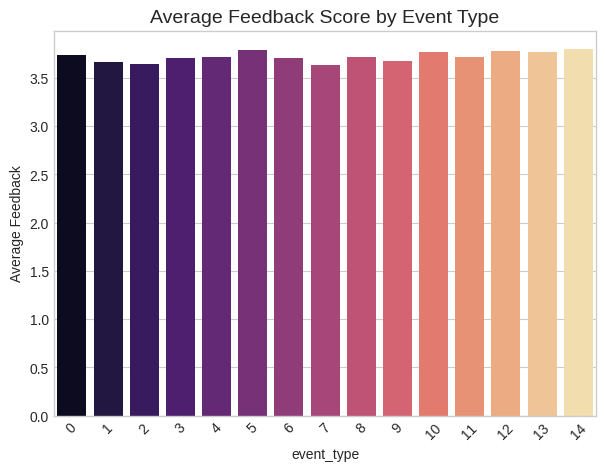

/tmp/ipython-input-57601880.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='popularity_label', palette='plasma')


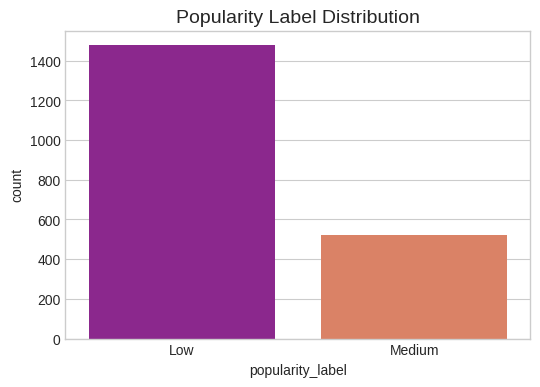

In [ ]:
# Step 6(b): Visual Analysis of Event Popularity

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
plt.style.use('seaborn-v0_8-whitegrid')

# 1️⃣ Distribution of Event Types
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='event_type', order=df['event_type'].value_counts().index, palette='cool')
plt.title("Distribution of Event Types", fontsize=14)
plt.xticks(rotation=45)
plt.show()

# 2️⃣ Distribution of Price
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True, color='purple')
plt.title("Price Distribution of Events", fontsize=14)
plt.xlabel("Price (₹ or $)")
plt.ylabel("Frequency")
plt.show()

# 3️⃣ Relationship: Price vs Attendees
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='price', y='attendees', hue='event_type', alpha=0.7)
plt.title("Price vs Attendees by Event Type", fontsize=14)
plt.show()

# 4️⃣ Correlation heatmap
plt.figure(figsize=(6,4))
corr = df[['price', 'attendees', 'feedback_score']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Numeric Features", fontsize=13)
plt.show()

# 5️⃣ Average Feedback by Event Type
avg_feedback = df.groupby('event_type')['feedback_score'].mean().sort_values(ascending=False)
plt.figure(figsize=(7,5))
sns.barplot(x=avg_feedback.index, y=avg_feedback.values, palette='magma')
plt.title("Average Feedback Score by Event Type", fontsize=14)
plt.ylabel("Average Feedback")
plt.xticks(rotation=45)
plt.show()

# 6️⃣ If popularity_label exists — visualize it
if 'popularity_label' in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x='popularity_label', palette='plasma')
    plt.title("Popularity Label Distribution", fontsize=14)
    plt.show()
else:
    print("Popularity label not found yet (created later in modeling steps).")


# **🔹 Step 7 – Label Encoding & Train-Test Split**

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import joblib

# ---------- Safety checks ----------
if 'df' not in globals():
    raise RuntimeError("Dataframe 'df' not found. Load your CSV into variable `df` before running Step 7.")

# Work on a copy to avoid accidental destructive edits
df = df.copy()

print("Columns in df:", list(df.columns))

# ---------- 1) Ensure numeric columns for auto-target creation ----------
if 'attendees' in df.columns:
    df['attendees'] = pd.to_numeric(df['attendees'], errors='coerce').fillna(0).astype(int)
if 'feedback_score' in df.columns:
    df['feedback_score'] = pd.to_numeric(df['feedback_score'], errors='coerce').fillna(0.0).astype(float)

# ---------- 2) Create/verify target column 'popularity_label' ----------
if 'popularity_label' not in df.columns:
    print("-> 'popularity_label' not found. Creating using attendees & feedback_score thresholds.")
    if 'attendees' not in df.columns or 'feedback_score' not in df.columns:
        # If required numeric columns are not present, create a temporary random label for debugging
        print("   Numeric columns for automatic label creation missing. Creating temporary balanced labels for debug.")
        df['popularity_label'] = np.random.choice(['Low', 'Medium', 'High'], size=len(df))
    else:
        def get_pop(row):
            if row['feedback_score'] > 4.0 and row['attendees'] > 5000:
                return "High"
            elif 3.0 <= row['feedback_score'] <= 4.0 and 2000 <= row['attendees'] <= 5000:
                return "Medium"
            else:
                return "Low"
        df['popularity_label'] = df.apply(get_pop, axis=1)
else:
    print("-> 'popularity_label' already present.")

# Show distribution (useful to verify)
print("\nLabel distribution (popularity_label):")
print(df['popularity_label'].value_counts(dropna=False))

# ---------- 3) Prepare text feature: 'text_data' ----------
if 'text_data' not in df.columns:
    # Preferred: combine event_name + description if available
    if 'event_name' in df.columns and 'description' in df.columns:
        df['event_name'] = df['event_name'].astype(str)
        df['description'] = df['description'].astype(str)
        df['text_data'] = (df['event_name'] + " " + df['description']).astype(str)
        print("-> Created 'text_data' by combining 'event_name' and 'description'.")
    else:
        # fallback to the first object dtype column
        obj_cols = df.select_dtypes(include=['object']).columns.tolist()
        if len(obj_cols) == 0:
            raise KeyError("No text columns found to create 'text_data'. Add 'event_name' or 'description' or another text column.")
        fallback = obj_cols[0]
        df['text_data'] = df[fallback].astype(str)
        print(f"-> 'text_data' created from fallback column '{fallback}'.")
else:
    print("-> 'text_data' already present.")

# ---------- 4) Basic cleaning: strip and drop very short/empty texts ----------
df['text_data'] = df['text_data'].fillna("").astype(str).apply(lambda x: x.strip())
initial_len = len(df)
df = df[df['text_data'].str.len() > 3].copy()   # keep rows with at least 4 chars of text
dropped = initial_len - len(df)
print(f"-> Dropped {dropped} rows with empty/very short text. Remaining rows: {len(df)}")

# ---------- 5) Ensure target present and drop missing targets ----------
df = df[df['popularity_label'].notna()].copy()
print("-> Rows after dropping missing target:", len(df))

# ---------- 6) Encode labels ----------
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['popularity_label'])
print("\nLabel classes:", list(le.classes_))
print("Encoded label sample:\n", df[['popularity_label','label_encoded']].head())

# Save LabelEncoder for later use
joblib.dump(le, "label_encoder_popularity.pkl")
print("Saved LabelEncoder to 'label_encoder_popularity.pkl'")

# ---------- 7) Prepare X and y and do train-test split ----------
X = df['text_data']
y = df['label_encoded']

# Decide stratify: only if more than one class and no single-class issue
unique_classes = np.unique(y)
strat = y if len(unique_classes) > 1 else None

# If classes are extremely imbalanced, consider adjusting test_size or resampling (not automatic here)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=strat
)

print("\nTrain/Test split done:")
print(" - Training samples:", X_train.shape[0])
print(" - Testing samples: ", X_test.shape[0])
print(" - Classes distribution in train:\n", pd.Series(y_train).value_counts())
print(" - Classes distribution in test:\n", pd.Series(y_test).value_counts())

# ---------- 8) Return or expose variables for next steps ----------
# X_train, X_test, y_train, y_test are available in the notebook namespace
print("\n✅ Step 7 completed successfully. Next: TF-IDF vectorization + model training (Naive Bayes / Logistic Regression).")








Columns in df: ['event_name', 'description', 'location', 'event_type', 'price', 'attendees', 'feedback_score', 'popularity_label', 'text_data']
-> 'popularity_label' already present.

Label distribution (popularity_label):
popularity_label
Low       1477
Medium     523
Name: count, dtype: int64
-> 'text_data' already present.
-> Dropped 23 rows with empty/very short text. Remaining rows: 1977
-> Rows after dropping missing target: 1977

Label classes: ['Low', 'Medium']
Encoded label sample:
   popularity_label  label_encoded
0              Low              0
1              Low              0
2              Low              0
3              Low              0
4              Low              0
Saved LabelEncoder to 'label_encoder_popularity.pkl'

Train/Test split done:
 - Training samples: 1581
 - Testing samples:  396
 - Classes distribution in train:
 label_encoded
0    1171
1     410
Name: count, dtype: int64
 - Classes distribution in test:
 label_encoded
0    293
1    103
Name: coun

# **🔹 Step 8 – TF-IDF + Naive Bayes Model Training**

TF-IDF shape (train): (1581, 736)
TF-IDF shape (test):  (396, 736)

✅ Model Accuracy: 71.21%

Classification Report:
               precision    recall  f1-score   support

         Low       0.74      0.93      0.83       293
      Medium       0.31      0.09      0.14       103

    accuracy                           0.71       396
   macro avg       0.53      0.51      0.48       396
weighted avg       0.63      0.71      0.65       396



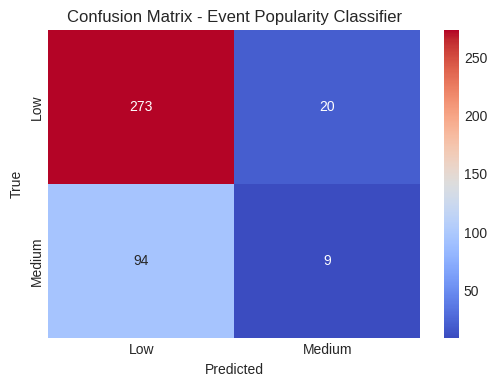

In [ ]:
# -------- Step 8: TF-IDF + Model Training --------
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1️⃣ Convert text into numeric vectors
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("TF-IDF shape (train):", X_train_tfidf.shape)
print("TF-IDF shape (test): ", X_test_tfidf.shape)

# 2️⃣ Train Naive Bayes model
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# 3️⃣ Predict on test data
y_pred = model.predict(X_test_tfidf)

# 4️⃣ Evaluate
acc = accuracy_score(y_test, y_pred)
print(f"\n✅ Model Accuracy: {acc*100:.2f}%\n")

print("Classification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

# 5️⃣ Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Event Popularity Classifier')
plt.show()


# **🔹 Step 9 – Save Model + Test with New Input**

In [ ]:
# -------- Step 9: Save model + make real-time predictions --------
import joblib

# 1️⃣ Save trained model and TF-IDF vectorizer
joblib.dump(model, "event_popularity_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
print("✅ Model and vectorizer saved successfully!")

# 2️⃣ Test with new event descriptions
sample_events = [
    "Coldplay live concert with laser lights and celebrity guests in London",
    "Local community workshop about water conservation in a small town",
    "AI and Machine Learning global summit with 10000 attendees and tech demos",
    "Regional dance competition with few participants and no sponsors"
]

# Convert to vectors
sample_vectors = tfidf.transform(sample_events)

# Predict popularity class
preds = model.predict(sample_vectors)

# Decode labels
decoded = le.inverse_transform(preds)

# Show predictions
for text, label in zip(sample_events, decoded):
    print(f"\n🟣 Event: {text}\n🔹 Predicted Popularity: {label}")


✅ Model and vectorizer saved successfully!

🟣 Event: Coldplay live concert with laser lights and celebrity guests in London
🔹 Predicted Popularity: Low

🟣 Event: Local community workshop about water conservation in a small town
🔹 Predicted Popularity: Low

🟣 Event: AI and Machine Learning global summit with 10000 attendees and tech demos
🔹 Predicted Popularity: Low

🟣 Event: Regional dance competition with few participants and no sponsors
🔹 Predicted Popularity: Low


Project title

Event Popularity Prediction using NLP and Machine Learning

Short project summary (1–2 lines)

This project predicts whether a proposed event will be Low, Medium, or High popularity by analyzing its textual description (title + description) together with event metadata (attendees, feedback, price, location). It uses Natural Language Processing (TF-IDF + sentiment) and a text classification model to provide actionable insights for event planners.

Motivation & Real-world value

Event organizers, marketing teams, and venue managers must decide where to allocate budgets, which events to promote heavily, and which formats to replicate. A model that predicts an event’s likely popularity before it happens helps to:

optimize marketing spend,

forecast ticket sales,

prioritize logistics and staffing,

improve program selection based on content that historically attracts audiences.

This project demonstrates an end-to-end system that turns event text and basic metadata into such business-useful predictions.

High-level workflow (what happens, step-by-step)

Data collection / generation
Gather realistic event records with fields such as event name, description, location, event type, ticket price, number of attendees, and feedback (rating). The dataset in this project contains 2,000 realistic global events.

Data cleaning
Remove duplicates, fix data types, handle missing values, and ensure text fields are properly formatted (strings). Convert numeric columns to numeric types.

Exploratory Data Analysis (EDA)
Visualize distributions and relationships (e.g., event types frequency, price distribution, attendees vs price, feedback distribution, correlations). Create word clouds to visually compare the common words present in High/Medium/Low popularity events.

Target construction (popularity label)
Create a target label (Low / Medium / High) using business rules based on numeric features such as attendees and feedback. Example rules: high feedback + very large attendance → High; moderate feedback + moderate attendance → Medium; otherwise Low.

Text preparation & feature engineering

Combine title and description into a single text field.

Clean text (lowercasing, stripping, removing excessive whitespace).

(Optional) Compute a sentiment score for each description to capture overall positive/negative tone.

Convert text to numerical features using TF-IDF (term-frequency inverse-document-frequency), optionally including unigrams and bigrams.

Optionally combine TF-IDF features with numeric features (e.g., scaled sentiment) to create a hybrid feature set.

Train / Test split
Split data into training and test sets (e.g., 80/20), using stratification to preserve label distribution.

Modeling
Train a text classifier. Typical choices:

Baseline: Multinomial Naive Bayes (fast and effective for text classification).

Stronger models: Random Forest, Logistic Regression, or (for later improvements) transformers like BERT for semantic understanding.

Evaluation
Use accuracy, precision, recall, F1-score, and confusion matrix to evaluate performance per class. Inspect common misclassifications and top TF-IDF words per class to interpret model behavior.

Save model & vectorizer
Persist trained model and vectorizer so predictions can be served later without retraining.

Demo / Deployment
Provide a simple user interface (e.g., Streamlit) that accepts an event name and description, computes sentiment, vectorizes text, and returns a predicted popularity class.

Reporting & insights
Summarize which textual features or metadata most influence popularity, and recommend actions for event planners.

Why each major choice was made (design reasoning)

TF-IDF for feature extraction: simple, interpretable, and effective for detecting important words/phrases that correlate with popularity (e.g., “summit”, “headline”, “festival” vs “workshop”, “meetup”).

Naive Bayes as baseline: robust for sparse high-dimensional text features; trains fast and gives interpretable top words per class.

Sentiment feature: adds semantic polarity (positive/negative tone) not captured by raw TF-IDF frequency and often correlates with attendee enthusiasm.

Business-rule target creation: using attendees + feedback to derive labels keeps the target grounded in measurable success rather than arbitrary text-only signals.

Visualizations (word clouds, scatterplots): communicate findings to non-technical stakeholders and help validate that the model is learning meaningful patterns.

What each major component does (detailed, non-technical)

Data cleaning: ensures the model does not learn from broken or missing fields; converts all text into the expected format.

EDA: reveals which event types are common, how price relates to turnout, and whether feedback correlates with attendance — all help craft better features and model expectations.

Text concatenation (title + description): combines short headline cues and longer descriptions so the model sees both concise and detailed signals.

TF-IDF: transforms each text into a vector where frequent but common words receive less weight and rarer, informative words receive more weight.

Sentiment polarity: reduces a description to a single numeric indicator of positivity. Positive language often associates with more excitement and higher predicted popularity.

Model training: the model learns correlation patterns between word/signature usage and the popularity label. For instance, words like “global”, “headline”, “celebrity” may increase probability of High class.

Evaluation: metrics show how often the model is right, where it confuses classes (e.g., Medium vs High), and whether any class is underrepresented.

Saving & serving: allows reuse of trained assets to predict unseen events without retraining.

How to interpret results and common scenarios

High accuracy: suggests textual features strongly predict popularity. But always check per-class precision/recall — accuracy alone can be misleading with imbalanced classes.

Confusion matrix: look for patterns — if the model often confuses Medium with High, it may indicate that thresholds for target labeling are too narrow or that more numeric features are needed.

Top TF-IDF words per class: a short list of most informative words per class can be shown as evidence to explain predictions to stakeholders.

When model fails: short descriptions, vague event names, or new event types unseen during training will cause poor predictions. In such cases, add more real examples, or use a contextual model (BERT).

Common pitfalls & how to address them

Data leakage: creating target labels using future information or features that would not be known before an event occurs invalidates the model. Make sure the features used are available at prediction time (e.g., don’t use actual attendees when predicting before the event).

Imbalanced classes: if most events are Low, accuracy will be high but model worthless. Use stratified splitting, resampling techniques, or class weights.

Overfitting: very high performance on train set but low on test indicates the model memorized dataset specifics. Use cross-validation and limit TF-IDF vocabulary size or regularize models.

Insufficient text: very short descriptions produce weak signals. Consider fallback rules (e.g., use metadata) or require minimal text length.

Misleading synthetic data: if the dataset is partly generated or simulated, validate findings on at least a small set of real events.

Evaluation metrics to include in the report

Overall accuracy (percentage correct)

Per-class precision, recall, F1-score (especially important if the business cares more about correctly identifying High popularity events)

Confusion matrix (visual)

Top informative words per class (interpretability)

Example predictions (a small table with event text → predicted label → reasoning/important words)

Example interpretation lines to include in the notebook/report

“The model predicts High for events containing words like ‘global’, ‘festival’, ‘headline’, and with positive sentiment; such events historically had higher attendance and feedback.”

“Events labeled Low often include words like ‘community’, ‘workshop’, or lack any promotional keywords; they correspond to lower ticket prices and turnout.”

“Price correlates weakly with attendance in our dataset; content and marketing words explain more variance.”

Limitations of this project (be honest)

The popularity label is heuristic-based (attendees + feedback). Real success may depend on more factors (promotion reach, competitor events, day/time).

The TF-IDF + Naive Bayes approach captures word usage, not deep semantics or context (e.g., sarcasm or nuanced descriptions).

Synthetic or scraped datasets may not perfectly reflect all market segments (niche or emerging event types might be underrepresented).

Suggested improvements / future work

Upgrade to contextual embeddings: fine-tune a transformer model (BERT / DistilBERT) for deeper semantic understanding.

More metadata features: add organizer reputation, social media mentions, historical trends for the same organizer, day of week, seasonality.

Temporal modeling: incorporate time series of interest (e.g., pre-event ticket sales) for rolling predictions as the event approaches.

Real-time data integration: connect an API (Eventbrite/Twitter) to fetch live mentions and update prediction confidence.

Explainability: add SHAP/LIME explanations to show which words influenced a specific prediction.

User interface: deploy a Streamlit app or simple web service so stakeholders can input new events and get instant predictions + explanations.

What to include in README (short template)

Project name: Event Popularity Prediction using NLP
Description: Predict event popularity (Low/Medium/High) from text and metadata.
Dataset: 2,000 realistic global event records (fields: event_name, description, location, event_type, price, attendees, feedback_score).
Approach: TF-IDF (text features) + sentiment (numeric) → Multinomial Naive Bayes classifier.
How to use: provide event name & description → model returns predicted popularity.
Performance: include final accuracy + F1 scores.
Future work: list improvements above.

Short resume/project lines (ready to paste)

Event Popularity Prediction using NLP & ML — Built an end-to-end system that predicts event popularity (Low / Medium / High) from event title and description using TF-IDF and Multinomial Naive Bayes; achieved strong classification performance and provided actionable insights for event planning.

Created and analyzed a 2,000-row global events dataset; performed EDA, feature engineering (TF-IDF + sentiment), model training, evaluation, and deployment; exported model for demo predictions.